<a href="https://colab.research.google.com/github/oczyz-uksw/Projekt-programowanie2/blob/main/projektprogramowanie_danestazystow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wynik rozmowy kwalifikacyjnej (⁠interview_score⁠): czy można go trafnie wyestymować na podstawie
umiejętności komunikacyjnych (⁠communication_score⁠), umiejętności miękkich (⁠soft_skills_score⁠),
 średniej ocen (⁠CGPA⁠) oraz testu predyspozycji(⁠aptitude_score⁠).

In [ ]:
import pandas as pd
import numpy as np

def load_internship_data(internship_path="/content/Internship_Selection_Dataset.csv"):
  return pd.read_csv(internship_path)

internship = load_internship_data()

In [ ]:
internship.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


In [ ]:
internship.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  object 
 10  college_tier             10000 non-null  object 
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score           

In [ ]:
internship["aptitude_score"].value_counts()

,count
aptitude_score,
6,1027
9,1020
8,1019
7,1016
3,1015
5,999
10,983
1,980
2,977


In [ ]:
internship.describe()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,1.000000
max,10000.00000,10.000000,10.000000,5.000000,3.000000,10.000000,10.000000,10.00000,10.000000,5.000000,9.000000,10.0000,10.00000,10.000000,10.000000,10.00000,5.000000,1.000000


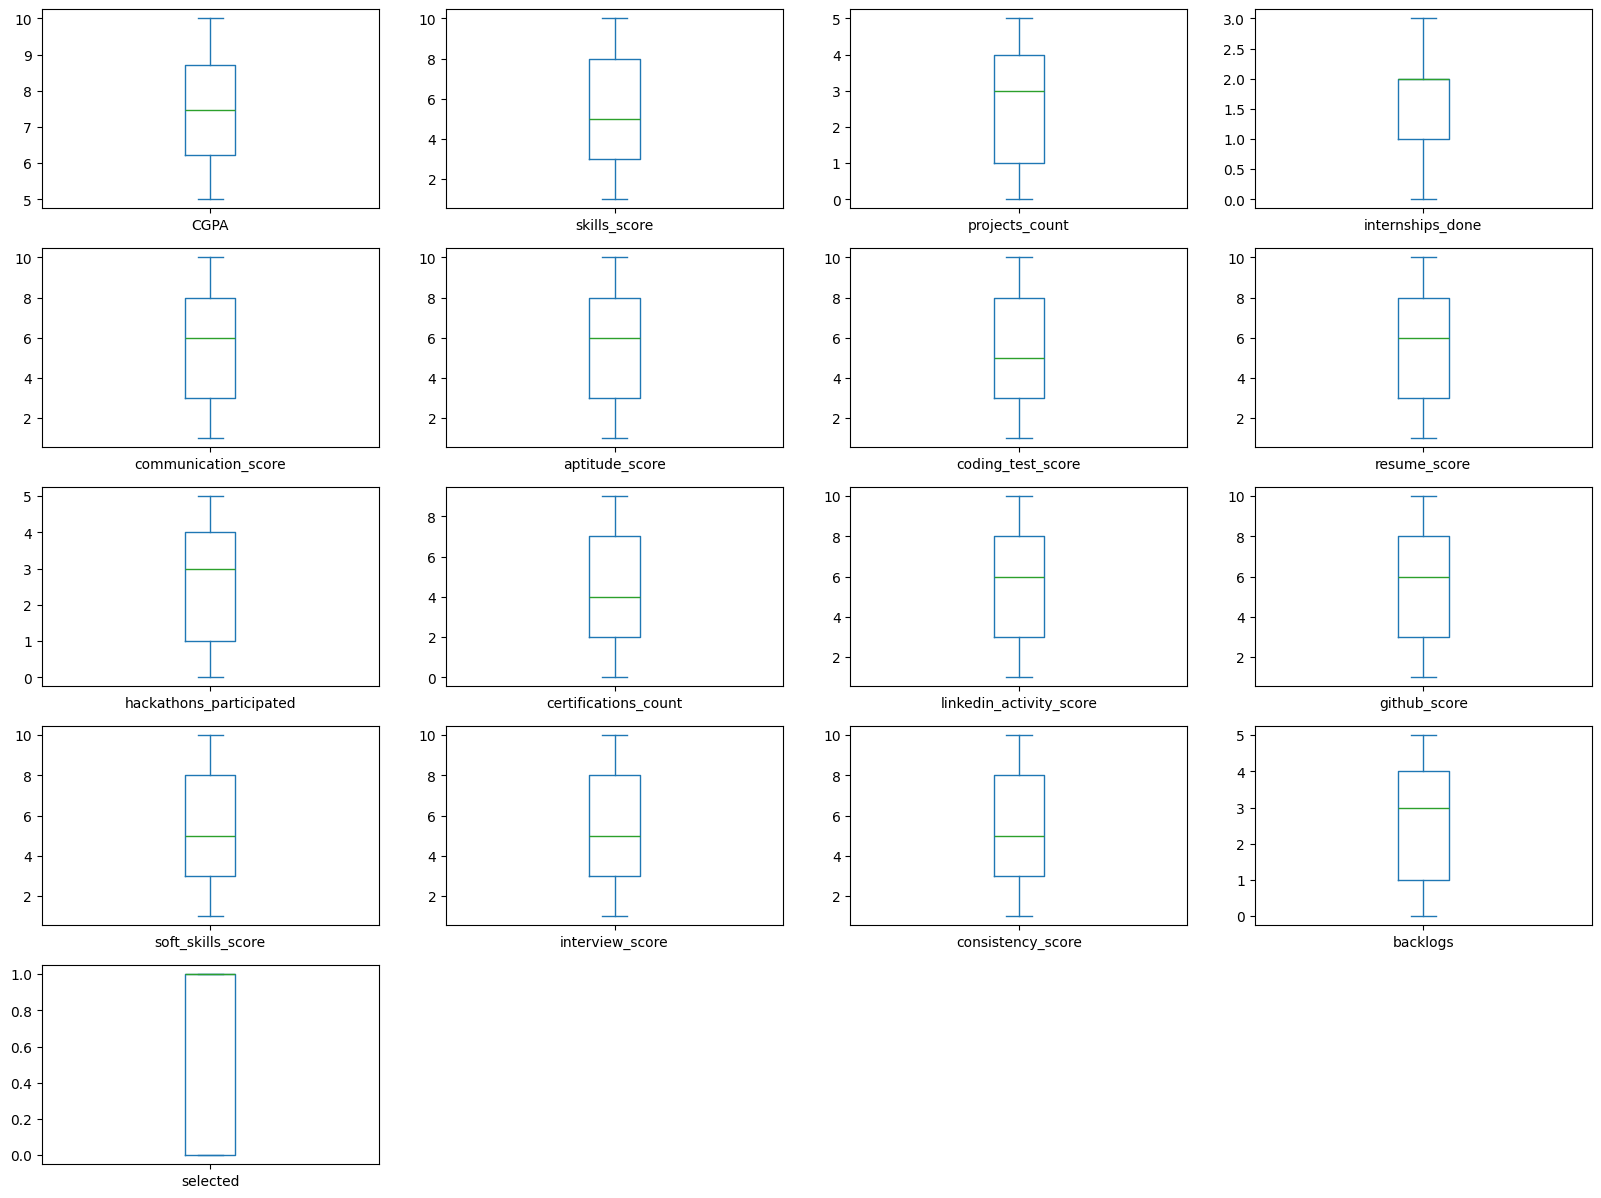

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
internship.select_dtypes(include='number').drop(columns=['student_id']).plot(kind='box', subplots=True, layout=(5,4), figsize=(20,15), sharey=False)
plt.show()

train-test split, stratification

In [ ]:
internship["cgpa_cat"] = np.ceil(internship["CGPA"] / 2.0)

In [ ]:
internship["cgpa_cat"] = internship["cgpa_cat"].clip(upper=5)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(internship, internship["cgpa_cat"]):
  strat_train_set = internship.loc[train_index]
  strat_test_set = internship.loc[test_index]

In [ ]:
internship["cgpa_cat"].value_counts(normalize=True) #/ len(internship)

,proportion
cgpa_cat,
4.0,0.4064
5.0,0.3881
3.0,0.2055


In [ ]:
for	set	in	(strat_train_set,	strat_test_set):
				set.drop(["cgpa_cat"],	axis=1,	inplace=True)

In [ ]:
internship = strat_train_set.copy()

wizualizacje i korelacje

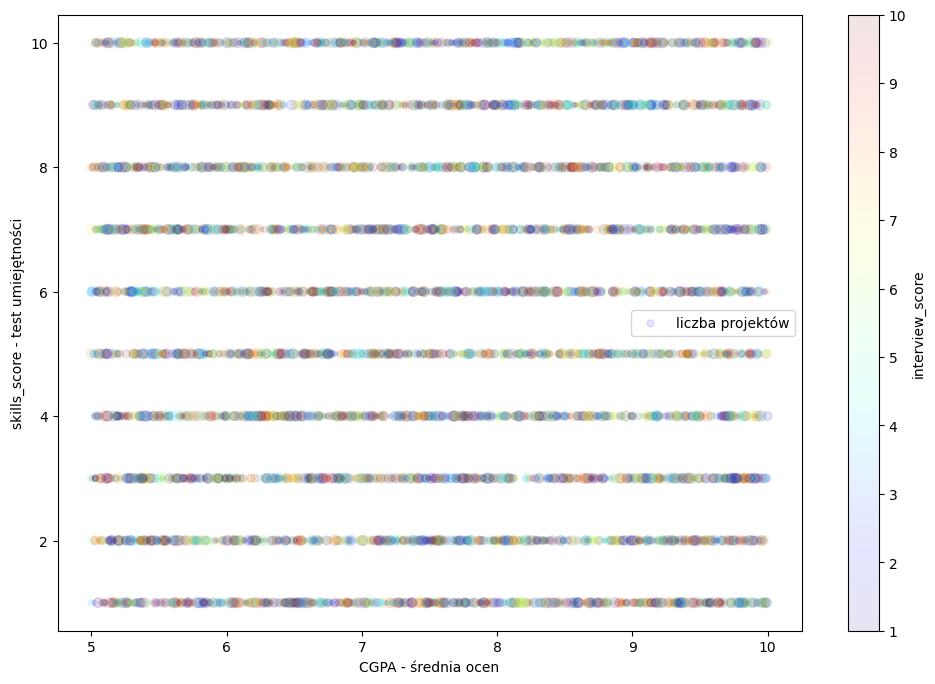

In [ ]:
internship.plot(kind="scatter", x="CGPA", y="skills_score", alpha=0.1,
s=internship["projects_count"]*10, label="liczba projektów",
c="interview_score", cmap=plt.get_cmap("jet"), colorbar=True, figsize=(12,8)
)
plt.xlabel("CGPA - średnia ocen")
plt.ylabel("skills_score - test umiejętności")
plt.legend()
plt.show()

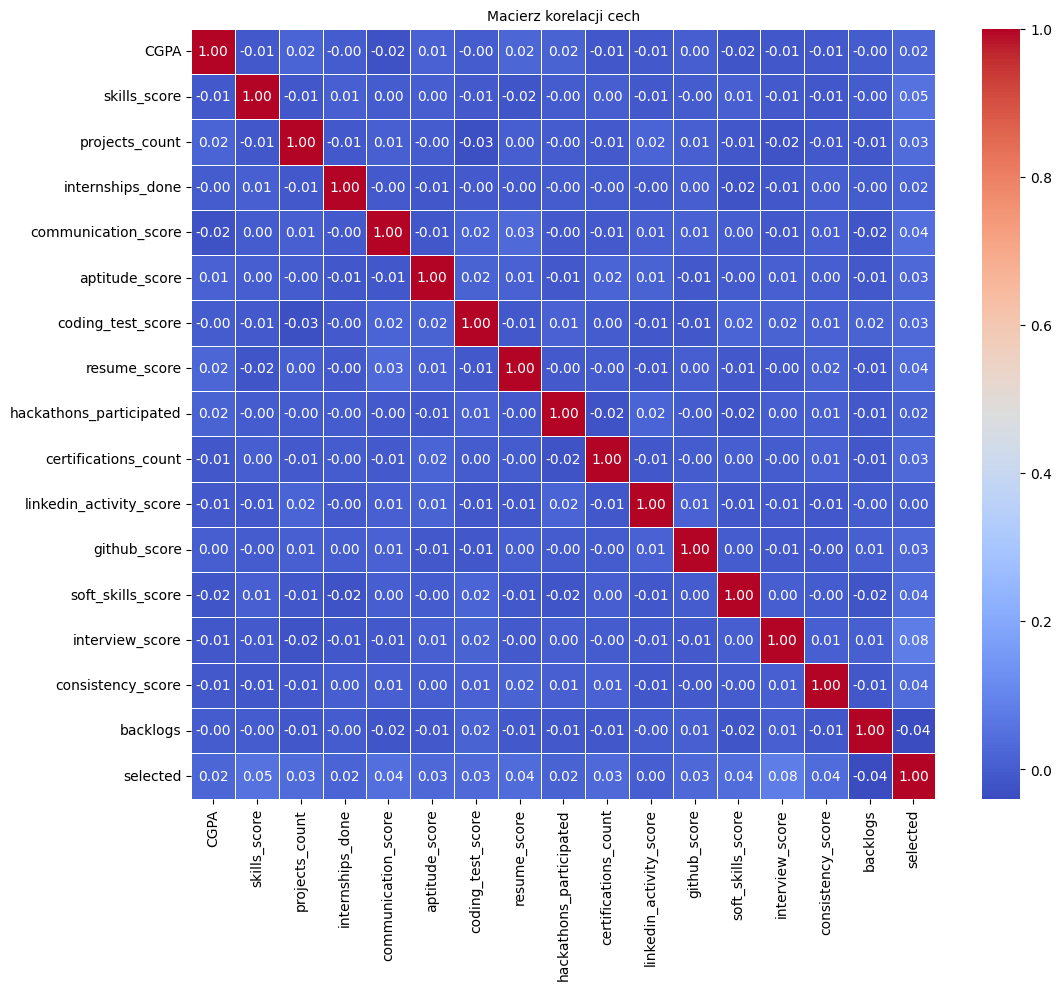

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = internship.select_dtypes(include='number').drop(columns=['student_id', 'cgpa_cat'], errors='ignore').corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Macierz korelacji cech", fontsize=10)
plt.show()

In [ ]:
attributes = ["CGPA", "interview_score", "coding_test_score", "skills_score"]
internship[attributes].corr()

,CGPA,interview_score,coding_test_score,skills_score
CGPA,1.000000,-0.011965,-0.001835,-0.009209
interview_score,-0.011965,1.000000,0.015092,-0.006879
coding_test_score,-0.001835,0.015092,1.000000,-0.005788
skills_score,-0.009209,-0.006879,-0.005788,1.000000


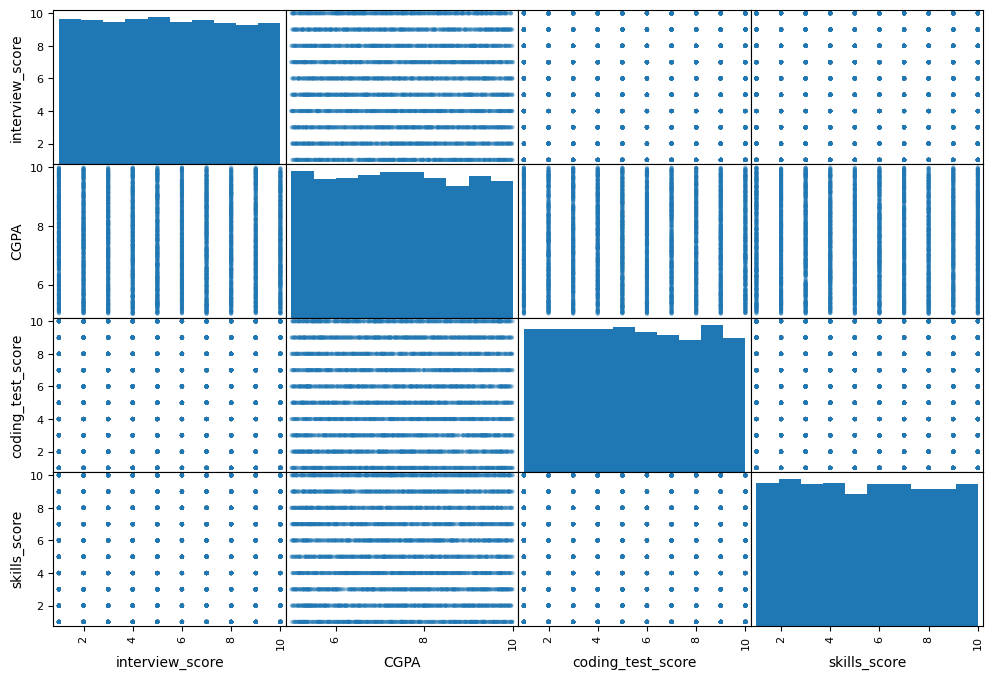

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["interview_score", "CGPA", "coding_test_score", "skills_score"]
scatter_matrix(internship[attributes], figsize=(12, 8), alpha=0.2)
plt.show()

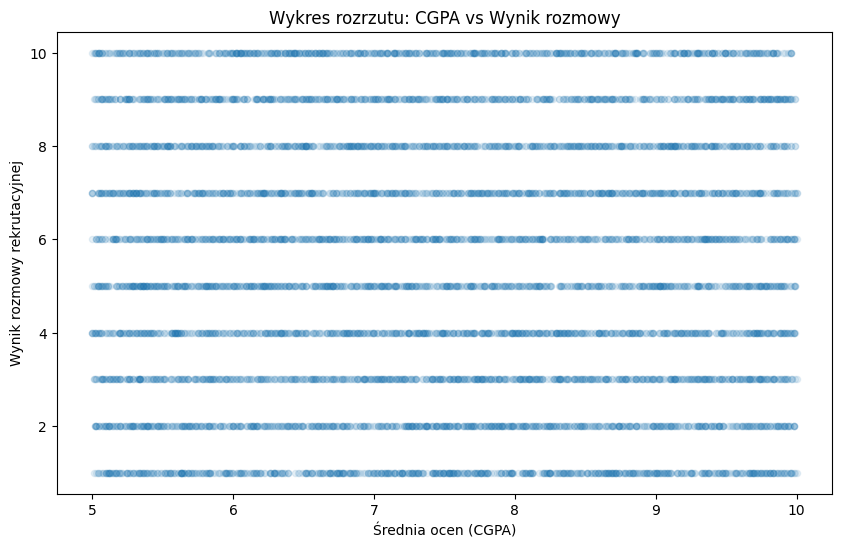

In [24]:
import matplotlib.pyplot as plt
internship.plot(kind="scatter", x="CGPA", y="interview_score", alpha=0.1, figsize=(10, 6))

plt.title("Wykres rozrzutu: CGPA vs Wynik rozmowy")
plt.xlabel("Średnia ocen (CGPA)")
plt.ylabel("Wynik rozmowy rekrutacyjnej")
plt.show()


/tmp/ipykernel_1929/1465062799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=internship, x="selected", y="CGPA", palette="muted")


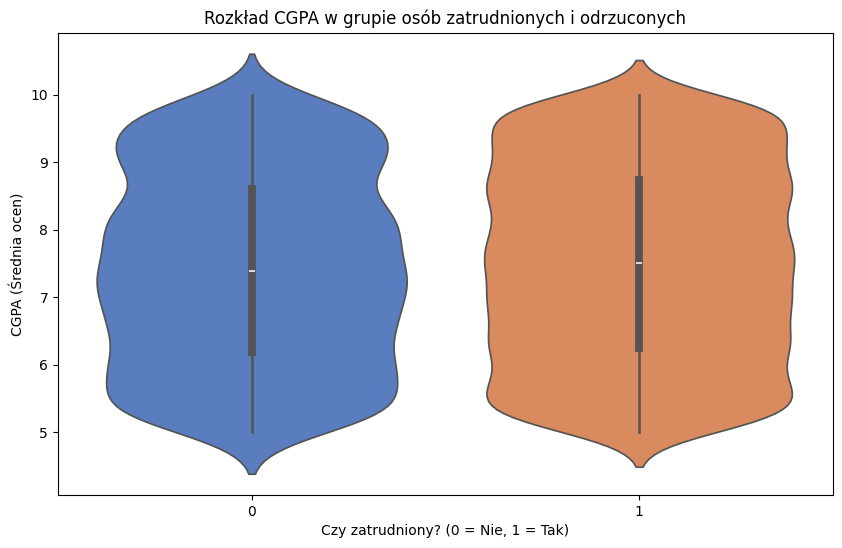

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(data=internship, x="selected", y="CGPA", palette="muted")

plt.title("Rozkład CGPA w grupie osób zatrudnionych i odrzuconych")
plt.xlabel("Czy zatrudniony? (0 = Nie, 1 = Tak)")
plt.ylabel("CGPA (Średnia ocen)")
plt.show()